<a href="https://colab.research.google.com/github/Bhavani827/NLP/blob/main/nlp_ass_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd

# text processing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Load and Preprocess Data

In [ ]:
data = pd.read_csv("/content/movie_reviews_dataset.csv")

print(data.head())

                                              review sentiment
0  This movie was amazing and I loved every part ...  positive
1                   The film was boring and too long  negative
2         What a fantastic performance by the actors  positive
3                    I did not like the story at all  negative
4      The cinematography was beautiful and engaging  positive


# Clean Text

In [ ]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]

    return " ".join(words)

data['clean_review'] = data['review'].apply(preprocess)

# Display Sample Processed Text

In [ ]:
print(data[['review','clean_review']].head())

                                              review  \
0  This movie was amazing and I loved every part ...   
1                   The film was boring and too long   
2         What a fantastic performance by the actors   
3                    I did not like the story at all   
4      The cinematography was beautiful and engaging   

                        clean_review  
0                movie amazing loved  
1                   film boring long  
2       fantastic performance actors  
3                     did like story  
4  cinematography beautiful engaging  


# Feature Extraction (TF-IDF)

In [ ]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data['clean_review'])
y = data['sentiment']

In [ ]:
print("Vocabulary Size:", len(vectorizer.vocabulary_))

Vocabulary Size: 50


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data['clean_review'])

In [ ]:
import pandas as pd

tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(tfidf_df.head())

   absolutely  acting   actors  amazing  beautiful   boring  brilliant  \
0         0.0     0.0  0.00000  0.65297    0.00000  0.00000        0.0   
1         0.0     0.0  0.00000  0.00000    0.00000  0.57735        0.0   
2         0.0     0.0  0.57735  0.00000    0.00000  0.00000        0.0   
3         0.0     0.0  0.00000  0.00000    0.00000  0.00000        0.0   
4         0.0     0.0  0.00000  0.00000    0.57735  0.00000        0.0   

   cinematography  depth      did  ...  visuals  wasting  watched  watching  \
0         0.00000    0.0  0.00000  ...      0.0      0.0      0.0       0.0   
1         0.00000    0.0  0.00000  ...      0.0      0.0      0.0       0.0   
2         0.00000    0.0  0.00000  ...      0.0      0.0      0.0       0.0   
3         0.00000    0.0  0.57735  ...      0.0      0.0      0.0       0.0   
4         0.57735    0.0  0.00000  ...      0.0      0.0      0.0       0.0   

   weak  wonderful  worst  worth  written  year  
0   0.0        0.0    0.0    0

# Train Logistic Regression Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Model Evaluation

In [ ]:
y_pred = model.predict(X_test)

# Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


# Precision, Recall, F1

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        11
    positive       1.00      1.00      1.00        12

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



# Confusion Matrix

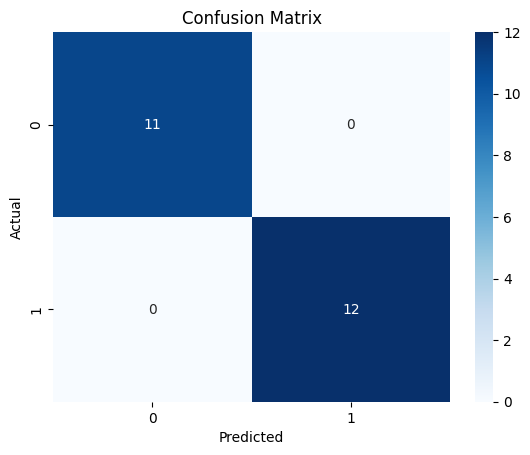

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Analysis (Comparison with Naive Bayes)

Logistic Regression and Naive Bayes are both widely used for text classification tasks. Naive Bayes assumes that all features are independent of each other, which simplifies calculations and makes it very fast for large datasets. However, this independence assumption is often unrealistic for natural language data. Logistic Regression does not make such strong assumptions and learns weights for each feature based on the training data. Because of this, Logistic Regression usually achieves better accuracy when sufficient training data is available. Naive Bayes performs well as a baseline model and works efficiently with smaller datasets. Logistic Regression, however, provides more flexible decision boundaries and interpretable coefficients. In many sentiment analysis tasks, Logistic Regression often produces higher precision and F1 scores compared to Naive Bayes. Therefore, Logistic Regression is generally preferred for more accurate text classification tasks.